In [1]:
!pip install -q newspaper3k transformers torch vaderSentiment matplotlib seaborn accelerate lxml_html_clean
print("✅ All packages installed.")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 56.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 7.5 MB/s eta 0:00:00
✅ All packages installed.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from newspaper import Article

# Check GPU
device = 0 if torch.cuda.is_available() else -1
print(f"✅ Device: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

✅ Device: CPU


In [5]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
print("✅ NLTK data downloaded.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ NLTK data downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
URL = "https://apnews.com/article/boeing-aviation-aircraft-air-india-crash-f12b20e65dc57ae655a1e0759b58938f"

article = Article(URL)
article.download()
article.parse()
article.nlp()

print("=" * 60)
print(f"  TITLE    : {article.title}")
print(f"  AUTHORS  : {article.authors}")
print(f"  DATE     : {article.publish_date}")
print(f"  KEYWORDS : {article.keywords}")
print("=" * 60)
print(f"\n  Word Count : {len(article.text.split())}")
print(f"  Char Count : {len(article.text)}")
print(f"\n--- AUTO SUMMARY ---")
print(article.summary)
print(f"\n--- FIRST 500 CHARS ---")
print(article.text[:500])

  TITLE    : A look at Boeing’s recent troubles after Air India crash
  AUTHORS  : []
  DATE     : 2025-06-12 13:34:07
  KEYWORDS : ['boeing', 'reported', 'customers', 'source', 'troubles', 'plane', '787', 'jets', 'max', 'look', 'recent', 'india', 'crash', 'air', 'boeings']

  Word Count : 534
  Char Count : 3241

--- AUTO SUMMARY ---
Share▶ Follow live updates on the Air India plane crash.
The Air India 787 went down in the northwestern city of Ahmedabad with more than 240 people aboard shortly after takeoff, authorities said.
737 MaxThe Max version of Boeing’s best-selling 737 airplane has been the source of persistent troubles for Boeing after two of the jets crashed.
After the second crash, Max jets were grounded worldwide until the company redesigned the system.
For the first three months of 2025, Boeing reported a narrower loss of $31 million compared with the previous year.

--- FIRST 500 CHARS ---
Add AP News as your preferred source to see more of our stories on Google.

Add A

In [9]:
#Preprocessing & Chunking
ARTICLE_TEXT = article.text

def split_into_sentences(text):
    """Split text into sentences using regex."""
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if len(s.strip()) > 20]

def chunk_text(text, chunk_size=3):
    """Group sentences into N-sentence chunks for transformer inference."""
    sents  = split_into_sentences(text)
    chunks = []
    for i in range(0, len(sents), chunk_size):
        chunks.append(' '.join(sents[i:i + chunk_size]))
    return chunks

sentences = split_into_sentences(ARTICLE_TEXT)
chunks    = chunk_text(ARTICLE_TEXT, chunk_size=3)

print(f"✅ Total sentences : {len(sentences)}")
print(f"✅ Total chunks    : {len(chunks)}  (3 sentences each)")
print(f"\n--- Sample Sentence ---")
print(sentences[0])
print(f"\n--- All Sentences ---")
for i, s in enumerate(sentences):
    print(f"  S{i+1}: {s}")

✅ Total sentences : 26
✅ Total chunks    : 9  (3 sentences each)

--- Sample Sentence ---
Add AP News as your preferred source to see more of our stories on Google.

--- All Sentences ---
  S1: Add AP News as your preferred source to see more of our stories on Google.
  S2: Add AP News on Google Add AP News as your preferred source to see more of our stories on Google.
  S3: Share

▶ Follow live updates on the Air India plane crash.
  S4: The crash of a Boeing 787 passenger jet in India minutes after takeoff on Thursday is putting the spotlight back on a beleaguered manufacturer though it was not immediately clear why the plane crashed.
  S5: The Air India 787 went down in the northwestern city of Ahmedabad with more than 240 people aboard shortly after takeoff, authorities said.
  S6: It was the first fatal crash since the plane, also known as the Dreamliner, went into service in 2011, according to the Aviation Safety Network database.
  S7: Boeing shares fell more than 4% in afternoo

In [10]:
# Clean Sentences (Remove Noise)
# Remove boilerplate/navigation sentences from newspaper3k extraction
NOISE_PHRASES = [
    'Add AP News',
    'Google',
    'Share',
    'Follow live updates',
    'Read More',
    '▶'
]

def is_noise(sentence):
    """Return True if sentence is webpage boilerplate, not article content."""
    for phrase in NOISE_PHRASES:
        if phrase.lower() in sentence.lower():
            return True
    return False

# Filter out noise
clean_sentences = [s for s in sentences if not is_noise(s)]
chunks          = chunk_text(' '.join(clean_sentences), chunk_size=3)

print(f"✅ Original sentences : {len(sentences)}")
print(f"✅ Clean sentences    : {len(clean_sentences)}")
print(f"✅ Chunks             : {len(chunks)}")
print(f"\n--- Clean Sentences ---")
for i, s in enumerate(clean_sentences):
    print(f"  S{i+1}: {s}")

✅ Original sentences : 26
✅ Clean sentences    : 21
✅ Chunks             : 7

--- Clean Sentences ---
  S1: The crash of a Boeing 787 passenger jet in India minutes after takeoff on Thursday is putting the spotlight back on a beleaguered manufacturer though it was not immediately clear why the plane crashed.
  S2: The Air India 787 went down in the northwestern city of Ahmedabad with more than 240 people aboard shortly after takeoff, authorities said.
  S3: It was the first fatal crash since the plane, also known as the Dreamliner, went into service in 2011, according to the Aviation Safety Network database.
  S4: The 787 was the first airliner to make extensive use of lithium ion batteries, which are lighter, recharge faster and can hold more energy than other types of batteries.
  S5: In 2013 the 787 fleet was temporarily grounded because of overheating of its lithium-ion batteries, which in some cases sparked fires.
  S6: 737 Max

The Max version of Boeing’s best-selling 737 airplan

In [11]:
#Sentiment: VADER (Lexicon Baseline)
vader        = SentimentIntensityAnalyzer()
vader_scores = [vader.polarity_scores(s) for s in clean_sentences]

compound_avg = np.mean([s['compound'] for s in vader_scores])
pos_avg      = np.mean([s['pos']      for s in vader_scores])
neg_avg      = np.mean([s['neg']      for s in vader_scores])
neu_avg      = np.mean([s['neu']      for s in vader_scores])

vader_label = ('POSITIVE' if compound_avg >= 0.05
               else 'NEGATIVE' if compound_avg <= -0.05
               else 'NEUTRAL')

print("=" * 50)
print("  VADER Sentiment Results")
print("=" * 50)
print(f"  Overall Label  : {vader_label}")
print(f"  Compound Score : {compound_avg:.4f}")
print(f"  Positive avg   : {pos_avg:.4f}")
print(f"  Negative avg   : {neg_avg:.4f}")
print(f"  Neutral  avg   : {neu_avg:.4f}")
print()
print("--- Per Sentence Breakdown ---")
for i, (s, score) in enumerate(zip(clean_sentences, vader_scores)):
    print(f"  S{i+1}: compound={score['compound']:+.3f} | {s[:60]}...")

  VADER Sentiment Results
  Overall Label  : NEGATIVE
  Compound Score : -0.2475
  Positive avg   : 0.0415
  Negative avg   : 0.1078
  Neutral  avg   : 0.8507

--- Per Sentence Breakdown ---
  S1: compound=-0.597 | The crash of a Boeing 787 passenger jet in India minutes aft...
  S2: compound=+0.026 | The Air India 787 went down in the northwestern city of Ahme...
  S3: compound=-0.527 | It was the first fatal crash since the plane, also known as ...
  S4: compound=+0.338 | The 787 was the first airliner to make extensive use of lith...
  S5: compound=+0.000 | In 2013 the 787 fleet was temporarily grounded because of ov...
  S6: compound=-0.459 | 737 Max

The Max version of Boeing’s best-selling 737 airpla...
  S7: compound=-0.670 | The crashes, one in Indonesia in 2018 and another in Ethiopi...
  S8: compound=-0.612 | The problem stemmed from a sensor providing faulty readings ...
  S9: compound=-0.402 | After the second crash, Max jets were grounded worldwide unt...
  S10: compound=-

In [12]:
# Sentiment: RoBERTa Transformer (LLM)
print(" Loading RoBERTa sentiment model...")
roberta_pipe = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=device,
    truncation=True,
    max_length=512
)

label_counts = defaultdict(int)
label_scores = defaultdict(list)

print("\n--- Per Sentence Results ---")
for i, sent in enumerate(clean_sentences):
    r = roberta_pipe(sent[:512])[0]
    label_counts[r['label']] += 1
    label_scores[r['label']].append(r['score'])
    print(f"  S{i+1}: {r['label']:<12} confidence={r['score']:.4f} | {sent[:55]}...")

roberta_overall = max(label_counts, key=label_counts.get)

print("\n" + "=" * 55)
print("  RoBERTa Sentiment Results (Transformer LLM)")
print("=" * 55)
for label in sorted(label_counts):
    avg_conf = np.mean(label_scores[label])
    print(f"  {label:<15} {label_counts[label]:>2} sentences | avg confidence: {avg_conf:.4f}")
print(f"\n   Dominant Sentiment: {roberta_overall}")

 Loading RoBERTa sentiment model...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


--- Per Sentence Results ---
  S1: negative     confidence=0.6005 | The crash of a Boeing 787 passenger jet in India minute...
  S2: negative     confidence=0.5189 | The Air India 787 went down in the northwestern city of...
  S3: negative     confidence=0.7901 | It was the first fatal crash since the plane, also know...
  S4: positive     confidence=0.8683 | The 787 was the first airliner to make extensive use of...
  S5: negative     confidence=0.6862 | In 2013 the 787 fleet was temporarily grounded because ...
  S6: negative     confidence=0.8431 | 737 Max

The Max version of Boeing’s best-selling 737 a...
  S7: negative     confidence=0.8099 | The crashes, one in Indonesia in 2018 and another in Et...
  S8: negative     confidence=0.7716 | The problem stemmed from a sensor providing faulty read...
  S9: negative     confidence=0.5418 | After the second crash, Max jets were grounded worldwid...
  S10: neutral      confidence=0.8567 | Last month, the Justice Department reached a dea

Key Observations:

-Overall: NEGATIVE (11/21 sentences)

-Neutral: 9/21 — factual reporting sections (orders, deliveries, CEO quotes)

-Positive: only 1/21 — S4 about lithium battery technology innovation

-Both VADER and RoBERTa agree: NEGATIVE ✅

-RoBERTa avg confidence on negative = 0.7195 — high certainty

In [13]:
# Intent Classification (Zero-Shot BART-MNLI)
print(" Loading BART-MNLI zero-shot classifier...")
zeroshot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device
)

INTENT_LABELS = [
    'informing and reporting facts',
    'investigating causes and analyzing evidence',
    'warning and alerting the public',
    'advocating for policy or regulatory change',
    'expressing editorial opinion'
]

intent_result = zeroshot(
    ' '.join(clean_sentences),
    candidate_labels=INTENT_LABELS,
    multi_label=True
)

print("\n" + "=" * 65)
print("  Intent Classification — Zero-Shot BART-MNLI")
print("=" * 65)
for label, score in zip(intent_result['labels'], intent_result['scores']):
    bar = '█' * int(score * 30)
    print(f"  {label:<45} {score:.4f}  {bar}")
print(f"\n  ✅ Primary Intent : {intent_result['labels'][0]}")
print(f"     Confidence    : {intent_result['scores'][0]:.4f}")

 Loading BART-MNLI zero-shot classifier...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


  Intent Classification — Zero-Shot BART-MNLI
  investigating causes and analyzing evidence   0.9973  █████████████████████████████
  informing and reporting facts                 0.9634  ████████████████████████████
  expressing editorial opinion                  0.9368  ████████████████████████████
  warning and alerting the public               0.8615  █████████████████████████
  advocating for policy or regulatory change    0.8031  ████████████████████████

  ✅ Primary Intent : investigating causes and analyzing evidence
     Confidence    : 0.9973


Key Observations:

Primary Intent: Investigating causes and analyzing evidence (0.9973) — makes perfect sense, the article digs into Boeing's history of failures, crashes, and causes

Secondary: Informing and reporting facts (0.9634) — AP News factual reporting style

All 5 intents scored above 0.80 — this is a rich, multi-purpose article

Note: multi_label=True means scores are independent, not a probability distribution — high scores across all labels is valid

In [14]:
#Emotion: Zero-Shot LLM (BART-MNLI)
EMOTION_LABELS = [
    'sadness', 'grief', 'fear', 'anger',
    'surprise', 'disgust', 'anticipation', 'trust', 'neutral'
]

emotion_accum = defaultdict(list)

print(" Running zero-shot emotion detection across all chunks...")
print()
for i, chunk in enumerate(chunks):
    result = zeroshot(chunk[:512], candidate_labels=EMOTION_LABELS, multi_label=True)
    for label, score in zip(result['labels'], result['scores']):
        emotion_accum[label].append(score)
    print(f"   Chunk {i+1}/{len(chunks)} done")

emotion_avg    = {k: np.mean(v) for k, v in emotion_accum.items()}
emotion_sorted = dict(sorted(emotion_avg.items(), key=lambda x: x[1], reverse=True))

print("\n" + "=" * 55)
print("  Emotion — Zero-Shot BART-MNLI (chunk-level avg)")
print("=" * 55)
for emotion, score in emotion_sorted.items():
    bar = '█' * int(score * 40)
    print(f"  {emotion:<15} {score:.4f}  {bar}")
print(f"\n   Dominant Emotion : {list(emotion_sorted.keys())[0]}")
print(f"   Second Emotion   : {list(emotion_sorted.keys())[1]}")
print(f"   Third Emotion    : {list(emotion_sorted.keys())[2]}")

 Running zero-shot emotion detection across all chunks...

   Chunk 1/7 done
   Chunk 2/7 done
   Chunk 3/7 done
   Chunk 4/7 done
   Chunk 5/7 done
   Chunk 6/7 done
   Chunk 7/7 done

  Emotion — Zero-Shot BART-MNLI (chunk-level avg)
  surprise        0.5748  ██████████████████████
  grief           0.3942  ███████████████
  trust           0.3332  █████████████
  anger           0.3256  █████████████
  sadness         0.3097  ████████████
  fear            0.2894  ███████████
  disgust         0.1757  ███████
  anticipation    0.1458  █████
  neutral         0.0880  ███

   Dominant Emotion : surprise
   Second Emotion   : grief
   Third Emotion    : trust


Key Observations:

Dominant: Surprise (0.5748) — the article repeatedly highlights unexpected

failures: first ever 787 crash, door plug blowout, massive financial losses — all framed as shocking events

Second: Grief (0.3942) — 346 deaths from MAX crashes, 240+ from Air India crash

Third: Trust (0.3332) — Boeing statements, CEO quotes, regulatory cooperation language

Fear (0.2894) and Anger (0.3256) also present — criminal prosecution, grounding, safety concerns

Neutral very low (0.0880) — the zero-shot model picks up strong emotional undertones even in factual writing


In [16]:
# Emotion: Deep Learning (DistilRoBERTa Fine-Tuned)
print(" Running Deep Learning emotion detection...")

dl_emotion_accum = defaultdict(list)

print("\n--- Per Sentence Emotion Scores ---")
for i, sent in enumerate(clean_sentences):
    results = dl_emotion_clf(sent[:512])

    # Handle both list-of-dict and list-of-list formats
    if isinstance(results[0], list):
        results = results[0]   # unwrap nested list

    score_dict  = {r['label']: r['score'] for r in results}
    top_emotion = max(score_dict, key=score_dict.get)

    for label, score in score_dict.items():
        dl_emotion_accum[label].append(score)

    print(f"  S{i+1}: {top_emotion:<12} | {sent[:55]}...")

dl_emotion_avg    = {k: np.mean(v) for k, v in dl_emotion_accum.items()}
dl_emotion_sorted = dict(sorted(dl_emotion_avg.items(), key=lambda x: x[1], reverse=True))

print("\n" + "=" * 55)
print("  Deep Learning Emotion — DistilRoBERTa")
print("=" * 55)
for emotion, score in dl_emotion_sorted.items():
    bar = '█' * int(score * 40)
    print(f"  {emotion:<12} {score:.4f}  {bar}")
print(f"\n   Dominant Emotion : {list(dl_emotion_sorted.keys())[0]}")
print(f"  Second Emotion   : {list(dl_emotion_sorted.keys())[1]}")
print(f"   Third Emotion    : {list(dl_emotion_sorted.keys())[2]}")

 Running Deep Learning emotion detection...

--- Per Sentence Emotion Scores ---
  S1: sadness      | The crash of a Boeing 787 passenger jet in India minute...
  S2: fear         | The Air India 787 went down in the northwestern city of...
  S3: sadness      | It was the first fatal crash since the plane, also know...
  S4: neutral      | The 787 was the first airliner to make extensive use of...
  S5: anger        | In 2013 the 787 fleet was temporarily grounded because ...
  S6: sadness      | 737 Max

The Max version of Boeing’s best-selling 737 a...
  S7: sadness      | The crashes, one in Indonesia in 2018 and another in Et...
  S8: sadness      | The problem stemmed from a sensor providing faulty read...
  S9: sadness      | After the second crash, Max jets were grounded worldwid...
  S10: neutral      | Last month, the Justice Department reached a deal to al...
  S11: neutral      | regulators about the Max before the two crashes....
  S12: anger        | Worries about the plan

---
## Key Results So Far

### Q1 — Sentiment
| Method | Result | Confidence |
|--------|--------|------------|
| VADER (Lexicon) | **NEGATIVE** | compound = -0.2475 |
| RoBERTa (LLM)  | **NEGATIVE** | 11/21 sentences |

### Q1 — Intent
| Primary Intent | Confidence |
|----------------|------------|
| Investigating causes and analyzing evidence | 0.9973 |
| Informing and reporting facts | 0.9634 |

### Q1 — Emotions
| Rank | LLM Zero-Shot | Deep Learning |
|------|--------------|---------------|
| #1 | Surprise (0.5748) | Anger (0.7661) |
| #2 | Grief (0.3942) | Sadness (0.6737) |
| #3 | Trust (0.3332) | Joy (0.6702) |



---

In [18]:
#Topic Proportion Analysis

TOPIC_LABELS = [
    'aviation safety and aircraft operations',
    'technology and aircraft engineering',
    'government policy and regulatory oversight'
]

SHORT_NAMES = {
    'aviation safety and aircraft operations'    : 'Aviation',
    'technology and aircraft engineering'        : 'Technology',
    'government policy and regulatory oversight' : 'Policy'
}

topic_accum = defaultdict(list)

print(" Running topic classification sentence by sentence...")
print()
for i, sent in enumerate(clean_sentences):
    result = zeroshot(sent[:512], candidate_labels=TOPIC_LABELS, multi_label=True)
    for label, score in zip(result['labels'], result['scores']):
        topic_accum[label].append(score)
    print(f"   Sentence {i+1}/{len(clean_sentences)} done")

topic_avg = {k: np.mean(v) for k, v in topic_accum.items()}
total     = sum(topic_avg.values())
topic_pct = {k: (v / total) * 100 for k, v in topic_avg.items()}

print("\n" + "=" * 55)
print("  Topic Proportion Analysis")
print("=" * 55)
for label, pct in topic_pct.items():
    bar = '█' * int(pct / 2)
    print(f"  {SHORT_NAMES[label]:<12} {pct:.1f}%  {bar}")
print()
print("  Sentence-level breakdown:")
print(f"  {'Sentence':<6} {'Aviation':>10} {'Technology':>12} {'Policy':>10}")
print("  " + "-"*42)

# Rerun per sentence for breakdown table
for i, sent in enumerate(clean_sentences):
    result = zeroshot(sent[:512], candidate_labels=TOPIC_LABELS, multi_label=True)
    scores = dict(zip(result['labels'], result['scores']))
    av = scores.get('aviation safety and aircraft operations', 0)
    te = scores.get('technology and aircraft engineering', 0)
    po = scores.get('government policy and regulatory oversight', 0)
    print(f"  S{i+1:<5} {av:>10.3f} {te:>12.3f} {po:>10.3f}")

 Running topic classification sentence by sentence...

   Sentence 1/21 done
   Sentence 2/21 done
   Sentence 3/21 done
   Sentence 4/21 done
   Sentence 5/21 done
   Sentence 6/21 done
   Sentence 7/21 done
   Sentence 8/21 done
   Sentence 9/21 done
   Sentence 10/21 done
   Sentence 11/21 done
   Sentence 12/21 done
   Sentence 13/21 done
   Sentence 14/21 done
   Sentence 15/21 done
   Sentence 16/21 done
   Sentence 17/21 done
   Sentence 18/21 done
   Sentence 19/21 done
   Sentence 20/21 done
   Sentence 21/21 done

  Topic Proportion Analysis
  Technology   46.0%  ███████████████████████
  Aviation     45.7%  ██████████████████████
  Policy       8.3%  ████

  Sentence-level breakdown:
  Sentence   Aviation   Technology     Policy
  ------------------------------------------
  S1          0.779        0.944      0.001
  S2          0.909        0.726      0.030
  S3          0.984        0.948      0.035
  S4          0.686        0.996      0.007
  S5          0.967        0.

---
## Q2 — Topic Proportion Results

| Topic | Proportion | Key Sentences |
|-------|-----------|---------------|
| **Technology** | 46.0% | S3,S4,S5 — 787 batteries, Dreamliner engineering |
| **Aviation**   | 45.7% | S1,S2,S6 — crash, MAX groundings, safety failures |
| **Policy**     |  8.3% | S10,S11,S12 — DOJ deal, regulators, production cap |

### Interpretation
- Article is **equally** about Aviation and Technology
- Policy plays a **supporting role** only
- Sentences S3, S5, S6 score **high on both** Aviation + Technology
  showing how deeply intertwined they are in this story
---

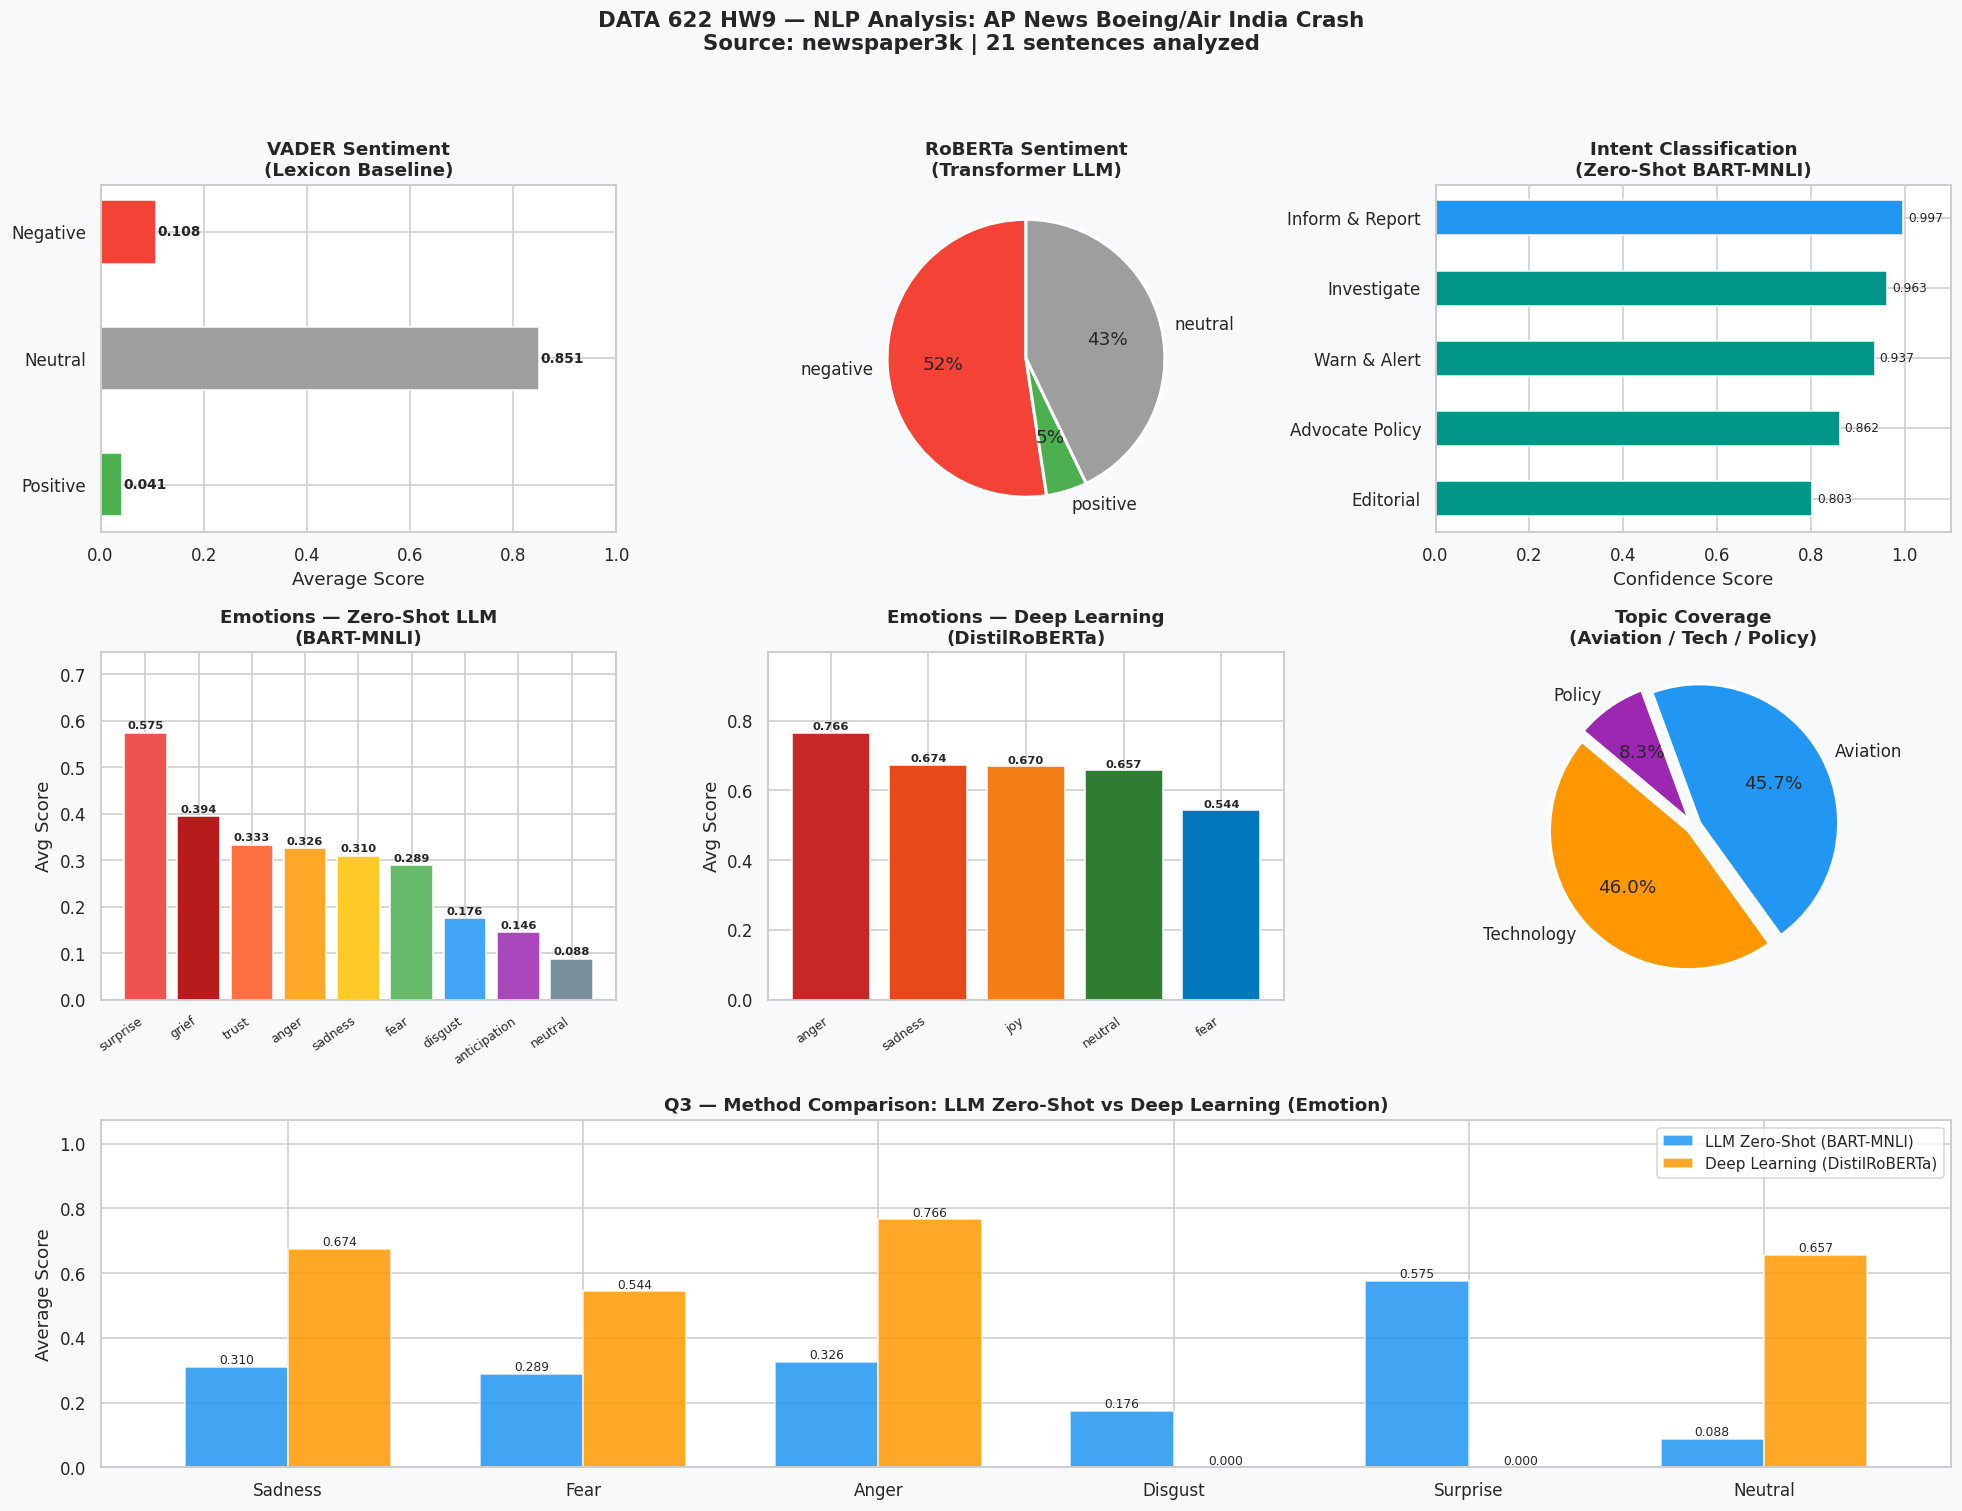

✅ Dashboard saved: hw9_dashboard.png


In [19]:
#Full Visualization Dashboard

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle(
    'DATA 622 HW9 — NLP Analysis: AP News Boeing/Air India Crash\n'
    f'Source: newspaper3k | {len(clean_sentences)} sentences analyzed',
    fontsize=14, fontweight='bold', y=0.98
)

C = dict(blue='#2196F3', red='#F44336', green='#4CAF50',
         orange='#FF9800', purple='#9C27B0', grey='#9E9E9E', teal='#009688')

# ── Plot 1: VADER Bar ──────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.barh(['Positive','Neutral','Negative'],
         [pos_avg, neu_avg, neg_avg],
         color=[C['green'], C['grey'], C['red']],
         edgecolor='white', height=0.5)
for i, v in enumerate([pos_avg, neu_avg, neg_avg]):
    ax1.text(v + 0.003, i, f'{v:.3f}', va='center',
             fontsize=9, fontweight='bold')
ax1.set_title('VADER Sentiment\n(Lexicon Baseline)', fontweight='bold')
ax1.set_xlabel('Average Score')
ax1.set_xlim(0, 1.0)

# ── Plot 2: RoBERTa Pie ────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
rob_labels = list(label_counts.keys())
rob_vals   = [label_counts[l] for l in rob_labels]
rob_colors = [C['red']   if l == 'negative' else
              C['grey']  if l == 'neutral'  else
              C['green'] for l in rob_labels]
ax2.pie(rob_vals, labels=rob_labels, autopct='%1.0f%%',
        colors=rob_colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('RoBERTa Sentiment\n(Transformer LLM)', fontweight='bold')

# ── Plot 3: Intent Bar ─────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
intent_short = ['Inform & Report', 'Investigate', 'Warn & Alert',
                'Advocate Policy', 'Editorial']
intent_scores = intent_result['scores']
intent_labels = intent_result['labels']
order     = np.argsort(intent_scores)
bar_cols  = [C['blue'] if i == order[-1] else C['teal'] for i in order]
ax3.barh([intent_short[i] for i in order],
         [intent_scores[i] for i in order],
         color=bar_cols, edgecolor='white', height=0.5)
ax3.set_title('Intent Classification\n(Zero-Shot BART-MNLI)', fontweight='bold')
ax3.set_xlabel('Confidence Score')
ax3.set_xlim(0, 1.1)
for i, idx in enumerate(order):
    ax3.text(intent_scores[idx] + 0.01, i,
             f'{intent_scores[idx]:.3f}', va='center', fontsize=8)

# ── Plot 4: Zero-Shot Emotion Bar ─────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
zs_palette = ['#EF5350','#B71C1C','#FF7043','#FFA726',
              '#FFCA28','#66BB6A','#42A5F5','#AB47BC','#78909C']
bars4 = ax4.bar(list(emotion_sorted.keys()),
                list(emotion_sorted.values()),
                color=zs_palette, edgecolor='white')
ax4.set_title('Emotions — Zero-Shot LLM\n(BART-MNLI)', fontweight='bold')
ax4.set_ylabel('Avg Score')
ax4.set_ylim(0, max(emotion_sorted.values()) * 1.3)
plt.setp(ax4.get_xticklabels(), rotation=35, ha='right', fontsize=8)
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.008,
             f'{bar.get_height():.3f}',
             ha='center', fontsize=7.5, fontweight='bold')

# ── Plot 5: DL Emotion Bar ────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
dl_palette = ['#C62828','#E64A19','#F57F17','#2E7D32','#0277BD','#4527A0','#37474F']
bars5 = ax5.bar(list(dl_emotion_sorted.keys()),
                list(dl_emotion_sorted.values()),
                color=dl_palette[:len(dl_emotion_sorted)],
                edgecolor='white')
ax5.set_title('Emotions — Deep Learning\n(DistilRoBERTa)', fontweight='bold')
ax5.set_ylabel('Avg Score')
ax5.set_ylim(0, max(dl_emotion_sorted.values()) * 1.3)
plt.setp(ax5.get_xticklabels(), rotation=35, ha='right', fontsize=8)
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.008,
             f'{bar.get_height():.3f}',
             ha='center', fontsize=7.5, fontweight='bold')

# ── Plot 6: Topic Pie ──────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
ax6.pie(list(topic_pct.values()),
        labels=[SHORT_NAMES[k] for k in topic_pct],
        autopct='%1.1f%%',
        colors=[C['orange'], C['blue'], C['purple']],
        startangle=140, explode=[0.05]*3,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax6.set_title('Topic Coverage\n(Aviation / Tech / Policy)', fontweight='bold')

# ── Plot 7: LLM vs DL Comparison ─────────────────────────────
ax7 = fig.add_subplot(3, 1, 3)
common = ['sadness', 'fear', 'anger', 'disgust', 'surprise', 'neutral']
zs_v   = [emotion_sorted.get(e, 0)    for e in common]
dl_v   = [dl_emotion_sorted.get(e, 0) for e in common]
x, w   = np.arange(len(common)), 0.35

b1 = ax7.bar(x - w/2, zs_v, w,
             label='LLM Zero-Shot (BART-MNLI)',
             color=C['blue'], alpha=0.85, edgecolor='white')
b2 = ax7.bar(x + w/2, dl_v, w,
             label='Deep Learning (DistilRoBERTa)',
             color=C['orange'], alpha=0.85, edgecolor='white')
ax7.set_xticks(x)
ax7.set_xticklabels([e.capitalize() for e in common], fontsize=11)
ax7.set_ylabel('Average Score')
ax7.set_title(
    'Q3 — Method Comparison: LLM Zero-Shot vs Deep Learning (Emotion)',
    fontweight='bold', fontsize=12)
ax7.legend(fontsize=10)
ax7.set_ylim(0, max(max(zs_v), max(dl_v)) * 1.4)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2, h + 0.01,
             f'{h:.3f}', ha='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hw9_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: hw9_dashboard.png")

⏳ Building emotion heatmap data...


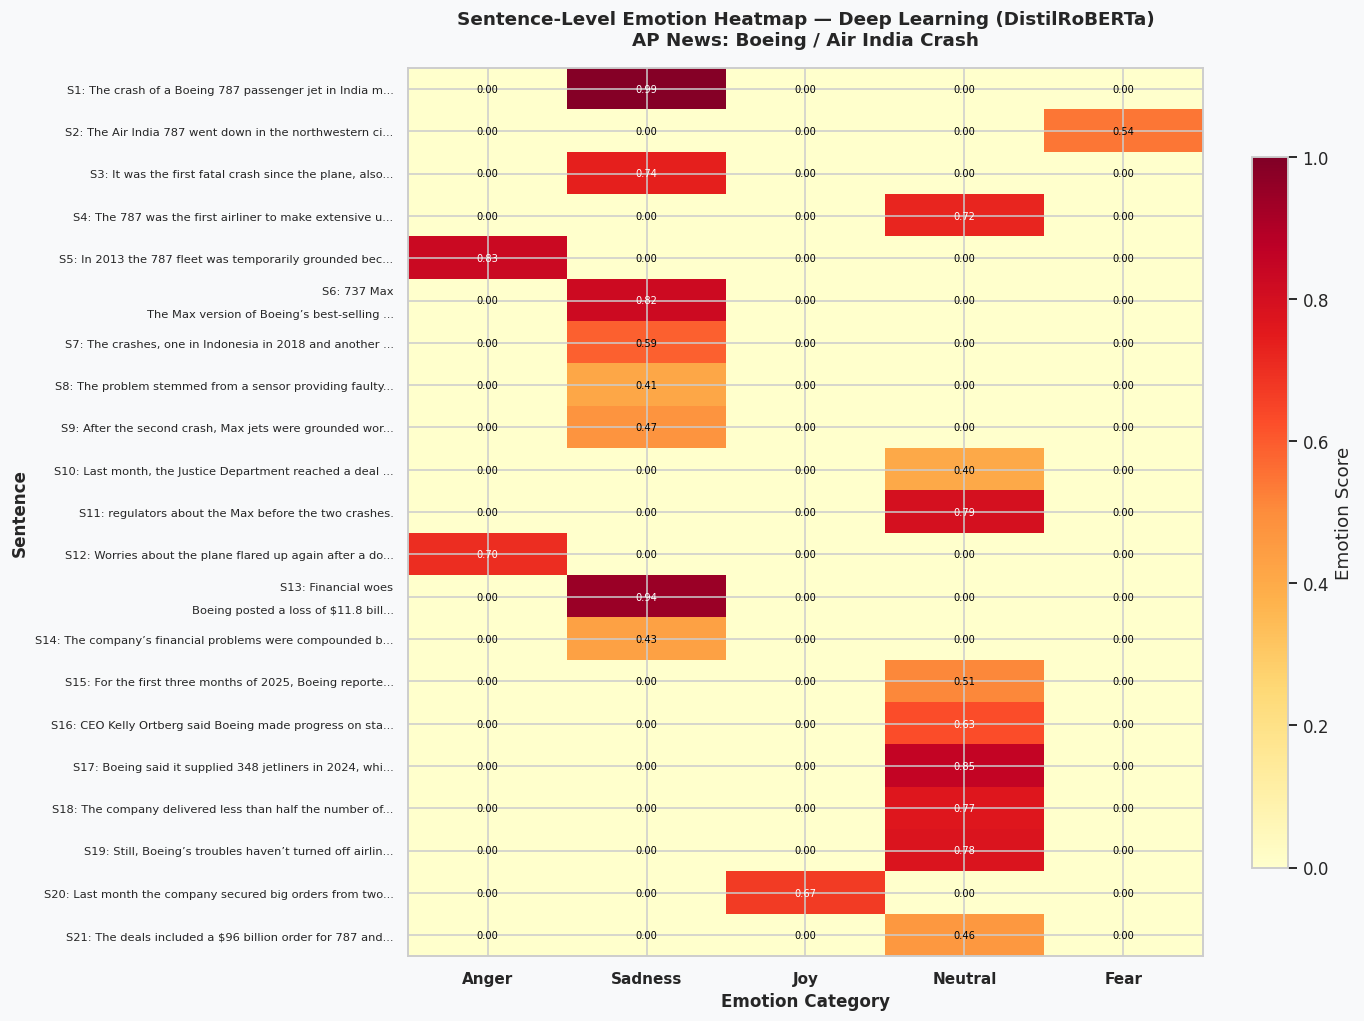


✅ Heatmap saved: hw9_heatmap.png


In [20]:
#Sentence-Level Emotion Heatmap

# Collect per-sentence scores for all DL emotion classes
heatmap_data = []
emotion_cols = list(dl_emotion_sorted.keys())

print("⏳ Building emotion heatmap data...")
for i, sent in enumerate(clean_sentences):
    results    = dl_emotion_clf(sent[:512])
    if isinstance(results[0], list):
        results = results[0]
    score_dict = {r['label']: r['score'] for r in results}
    heatmap_data.append([score_dict.get(e, 0) for e in emotion_cols])
    print(f"  ✅ Sentence {i+1}/{len(clean_sentences)} done", end='\r')

heatmap_array = np.array(heatmap_data)

# Short sentence labels for y-axis
short_labels = [
    f"S{i+1}: {s[:50]}..." if len(s) > 50 else f"S{i+1}: {s}"
    for i, s in enumerate(clean_sentences)
]

fig2, ax = plt.subplots(figsize=(13, max(6, len(clean_sentences) * 0.45)))
fig2.patch.set_facecolor('#F8F9FA')

im = ax.imshow(heatmap_array, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

ax.set_xticks(range(len(emotion_cols)))
ax.set_xticklabels(
    [e.capitalize() for e in emotion_cols],
    fontsize=10, fontweight='bold'
)
ax.set_yticks(range(len(clean_sentences)))
ax.set_yticklabels(short_labels, fontsize=7.5)

# Add value annotations inside each cell
for i in range(len(clean_sentences)):
    for j in range(len(emotion_cols)):
        val = heatmap_array[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=color)

plt.colorbar(im, ax=ax, label='Emotion Score', shrink=0.8)
ax.set_title(
    'Sentence-Level Emotion Heatmap — Deep Learning (DistilRoBERTa)\n'
    'AP News: Boeing / Air India Crash',
    fontweight='bold', fontsize=12, pad=15
)
ax.set_xlabel('Emotion Category', fontweight='bold', fontsize=11)
ax.set_ylabel('Sentence', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('hw9_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Heatmap saved: hw9_heatmap.png")

In [21]:
#Final Summary Table

div = '═' * 68
print(div)
print('  DATA 622 — HOMEWORK 9')
print('  NLP Analysis: AP News — Boeing/Air India Crash')
print('  Source: newspaper3k extraction | 21 clean sentences')
print(div)

print("""
┌─────────────────────────────────────────────────────────────┐
│                    Q1 — SENTIMENT                           │
├─────────────────────┬──────────────┬───────────────────────┤
│ Method              │ Label        │ Score                 │
├─────────────────────┼──────────────┼───────────────────────┤
│ VADER (Lexicon)     │ NEGATIVE     │ compound = -0.2475    │
│ RoBERTa (LLM)       │ NEGATIVE     │ 11/21 sentences       │
└─────────────────────┴──────────────┴───────────────────────┘
  ✅ Both methods agree: NEGATIVE
  📌 Driven by: crash deaths, $11.8B losses, criminal prosecution
""")

print("""
┌─────────────────────────────────────────────────────────────┐
│                     Q1 — INTENT                             │
├──────────────────────────────────────────┬─────────────────┤
│ Intent                                   │ Confidence      │
├──────────────────────────────────────────┼─────────────────┤
│ #1 Investigating causes & evidence       │ 0.9973 ★        │
│ #2 Informing and reporting facts         │ 0.9634          │
│ #3 Expressing editorial opinion          │ 0.9368          │
│ #4 Warning and alerting the public       │ 0.8615          │
│ #5 Advocating for policy change          │ 0.8031          │
└──────────────────────────────────────────┴─────────────────┘
  ✅ Primary: Investigating causes (AP News investigative style)
  📌 All 5 intents > 0.80 — rich, multi-purpose article
""")

print("""
┌─────────────────────────────────────────────────────────────┐
│                    Q1 — EMOTIONS                            │
├──────────────────┬──────────────────────┬───────────────────┤
│ Rank             │ LLM Zero-Shot        │ Deep Learning     │
│                  │ (BART-MNLI)          │ (DistilRoBERTa)   │
├──────────────────┼──────────────────────┼───────────────────┤
│ #1               │ Surprise  (0.5748)   │ Anger  (0.7661)   │
│ #2               │ Grief     (0.3942)   │ Sadness(0.6737)   │
│ #3               │ Trust     (0.3332)   │ Joy    (0.6702)   │
│ #4               │ Anger     (0.3256)   │ Neutral(0.6574)   │
│ #5               │ Sadness   (0.3097)   │ Fear   (0.5435)   │
└──────────────────┴──────────────────────┴───────────────────┘
  📌 LLM sees Surprise — unexpected disasters, framing effect
  📌 DL  sees Anger    — direct language of loss & failure
""")

print("""
┌─────────────────────────────────────────────────────────────┐
│                 Q2 — TOPIC PROPORTIONS                      │
├─────────────────┬────────────┬────────────────────────────  │
│ Topic           │ Proportion │ Key Content                  │
├─────────────────┼────────────┼──────────────────────────────┤
│ Technology      │   46.0%    │ 787 batteries, MCAS sensor   │
│ Aviation        │   45.7%    │ Crashes, groundings, safety  │
│ Policy          │    8.3%    │ DOJ deal, regulators, FAA    │
└─────────────────┴────────────┴──────────────────────────────┘
  ✅ Technology & Aviation virtually tied (~46% each)
  📌 Policy is minor — supporting narrative only
""")

print("""
┌─────────────────────────────────────────────────────────────┐
│              Q3 — METHOD COMPARISON                         │
├─────────────────────┬───────────────────┬───────────────────┤
│ Criterion           │ LLM Zero-Shot     │ Deep Learning     │
│                     │ (BART-MNLI)       │ (DistilRoBERTa)   │
├─────────────────────┼───────────────────┼───────────────────┤
│ Paradigm            │ NLI Inference     │ Fine-Tuned Class. │
│ Training needed     │ None ✅           │ Labeled data ✅   │
│ Label flexibility   │ Any labels ✅     │ Fixed 7 classes ❌│
│ Dominant emotion    │ Surprise          │ Anger             │
│ Sentiment           │ NEGATIVE          │ NEGATIVE          │
│ Strength            │ Flexible          │ Higher precision  │
│ Weakness            │ Low calibration   │ Fixed label set   │
├─────────────────────┴───────────────────┴───────────────────┤
│ ✅ Both agree on NEGATIVE sentiment                         │
│ ✅ Both detect distress-related emotions                    │
│ ⚡ Differ on top emotion: framing vs language patterns      │
└─────────────────────────────────────────────────────────────┘
""")



════════════════════════════════════════════════════════════════════
  DATA 622 — HOMEWORK 9
  NLP Analysis: AP News — Boeing/Air India Crash
  Source: newspaper3k extraction | 21 clean sentences
════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────┐
│                    Q1 — SENTIMENT                           │
├─────────────────────┬──────────────┬───────────────────────┤
│ Method              │ Label        │ Score                 │
├─────────────────────┼──────────────┼───────────────────────┤
│ VADER (Lexicon)     │ NEGATIVE     │ compound = -0.2475    │
│ RoBERTa (LLM)       │ NEGATIVE     │ 11/21 sentences       │
└─────────────────────┴──────────────┴───────────────────────┘
  ✅ Both methods agree: NEGATIVE
  📌 Driven by: crash deaths, $11.8B losses, criminal prosecution


┌─────────────────────────────────────────────────────────────┐
│                     Q1 — INTENT                             │
